In [2]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. SETUP & DATA LOADING (CORRECTED TIMEFRAME)
# -------------------------------------------------------------------------
csv_path = "cs_bisnode_panel.csv" 
data = pd.read_csv(csv_path)

# 1. FILTER PANEL TIMEFRAME IMMEDIATELY
# We keep 2010-2015. 
# We need 2010/2011 for past lags (history).
# We need 2014/2015 for future growth (target).
data = data.query("year >= 2010 & year <= 2015")

# Drop variables with too many NAs 
data = data.drop(columns=["COGS", "finished_prod", "net_dom_sales", "net_exp_sales", "wages"])

# -------------------------------------------------------------------------
# 2. LABEL ENGINEERING 
# -------------------------------------------------------------------------

# Add all missing year and comp_id combinations
data = (
    data.set_index(["year", "comp_id"])
    .unstack(fill_value="toReplace")
    .stack()
    .reset_index()
)
data = data.replace("toReplace", np.nan)

# Generate status_alive
data["status_alive"] = (data["sales"] > 0 & (False == data["sales"].isna())).astype(int)

# --- TARGET VARIABLE: FAST GROWTH ---

# Sort to ensure lags/leads work
data = data.sort_values(by=["comp_id", "year"])

# Get future sales (2 years ahead). 
# For a 2012 row, this pulls the 2014 sales value.
data["sales_lead2"] = data.groupby("comp_id")["sales"].shift(-2)

# Calculate Target: CAGR >= 20% (approx 44% total growth over 2 years)
# Logic: If alive AND (Sales2014 >= 1.44 * Sales2012) -> 1, else 0.
data["fast_growth"] = np.where(
    (data["status_alive"] == 1) & 
    (data["sales_lead2"] >= 1.44 * data["sales"]), 
    1, 
    0
)

# If data in 2014 is missing (firm exited or data error), treat as No Growth (0)
data["fast_growth"] = np.where(data["sales_lead2"].isna(), 0, data["fast_growth"])

# -------------------------------------------------------------------------
# 3. FEATURE ENGINEERING (Standard Steps)
# -------------------------------------------------------------------------

# Log Sales & Transformations
data["sales"] = np.where(data["sales"] < 0, 1, data["sales"]) 
data = data.assign(
    ln_sales=np.where(data["sales"] > 0, np.log(data["sales"]), np.nan),
    sales_mil=data["sales"] / 1000000,
    sales_mil_log=np.where(data["sales"] > 0, np.log(data["sales"] / 1000000), np.nan),
)

data["d1_sales_mil_log"] = data["sales_mil_log"] - data.groupby("comp_id")["sales_mil_log"].shift(1)

# Age & New Firm Flags
data["age"] = np.where(data["year"] - data["founded_year"] < 0, 0, data["year"] - data["founded_year"])
data["new"] = np.where(((data["age"] <= 1) | (data["balsheet_notfullyear"] == 1)), 1, 0)
data["d1_sales_mil_log"] = np.where(data["new"] == 1, 0, data["d1_sales_mil_log"])
data["d1_sales_mil_log"] = np.where(data["d1_sales_mil_log"].isna(), 0, data["d1_sales_mil_log"])

# -------------------------------------------------------------------------
# 4. SAMPLE DESIGN
# -------------------------------------------------------------------------

# Filter for the base year 2012
data = data.query("year == 2012 & status_alive == 1")

# Filter size: 1k EUR to 10m EUR (Same as exit prediction to remove tiny/huge outliers)
data = data.query("sales_mil <= 10 & sales_mil >= 0.001")

# Check the balance of the target
print("Class Balance for Fast Growth:")
print(data["fast_growth"].value_counts())
print(data["fast_growth"].describe())

# Save workfile for feature engineering
data.to_csv("work5_growth.csv", index=False)

# -------------------------------------------------------------------------
# 5. FURTHER FEATURE ENGINEERING (CORRECTED)
# -------------------------------------------------------------------------
# Reload to ensure clean index
data = pd.read_csv("work5_growth.csv")

# 1. Industry Categories
data["ind2_cat"] = data["ind2"].copy()
data["ind2_cat"] = np.where(data["ind2"] > 56, 60, data["ind2_cat"])
data["ind2_cat"] = np.where(data["ind2"] < 26, 20, data["ind2_cat"])
data["ind2_cat"] = np.where((data["ind2"] < 55) & (data["ind2"] > 35), 40, data["ind2_cat"])
data["ind2_cat"] = np.where(data["ind2"] == 31, 30, data["ind2_cat"])
data["ind2_cat"] = np.where(data["ind2"].isna(), 99, data["ind2_cat"])

# 2. Firm Characteristics (Variables missing in previous snippet)
data["age2"] = data["age"] ** 2
data["foreign_management"] = np.where(
    data["foreign"] >= 0.5, 1, np.where(data["foreign"].isna(), np.nan, 0)
)
data["gender_m"] = data["gender"].astype("category")
data["m_region_loc"] = data["region_m"].astype("category") # <--- THIS WAS THE MISSING KEY

# 3. Asset Flags & Ratios
data["total_assets_bs"] = data["intang_assets"] + data["curr_assets"] + data["fixed_assets"]

pl_names = ["extra_exp", "extra_inc", "extra_profit_loss", "inc_bef_tax", "inventories", "material_exp", "profit_loss_year", "personnel_exp"]
bs_names = ["intang_assets", "curr_liab", "fixed_assets", "liq_assets", "curr_assets", "share_eq", "subscribed_cap", "tang_assets"]

# Create ratios
data[[col + "_pl" for col in pl_names]] = data[pl_names].div(data["sales"], axis="index")
data[[col + "_bs" for col in bs_names]] = data[bs_names].div(data["total_assets_bs"], axis="index").replace((np.inf, -np.inf, np.nan), (0, 0, 0))

# 4. CEO Age & Imputation
data["ceo_age"] = data["year"] - data["birth_year"]
data["ceo_age"] = np.where(data["ceo_age"].isna(), data["ceo_age"].mean(), data["ceo_age"])
data["ceo_young"] = (data["ceo_age"] < 40).astype(int)

# 5. Winsorizing / Flags (Brief version to prevent errors)
# NOTE: In a full run, you should include the full "flag_high", "flag_low" blocks here.
# For now, we ensure the variables used in dropna exist.

# 6. Drop missing key vars
# Now 'm_region_loc' exists, so this will work.
data = data.dropna(subset=["liq_assets_bs", "foreign", "ind", "age", "material_exp_pl", "m_region_loc"])

# -------------------------------------------------------------------------
# 6. EXPORT FINAL DATASET
# -------------------------------------------------------------------------
data.to_csv("bisnode_firms_clean_growth.csv", index=False)
print("Data preparation complete. Saved to 'bisnode_firms_clean_growth.csv'")

/var/folders/rf/vp5tfjs17hl01_zcsfh3prpm0000gn/T/ipykernel_58862/2554923557.py:33: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack()
/var/folders/rf/vp5tfjs17hl01_zcsfh3prpm0000gn/T/ipykernel_58862/2554923557.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace("toReplace", np.nan)
/Users/elenezuroshvili/opt/anaconda3/envs/daenv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Class Balance for Fast Growth:
fast_growth
0    16603
1     5120
Name: count, dtype: int64
count    21723.000000
mean         0.235695
std          0.424442
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: fast_growth, dtype: float64
Data preparation complete. Saved to 'bisnode_firms_clean_growth.csv'


In [4]:
# -------------------------------------------------------------------------
# FIX: CREATE MISSING VARIABLES FOR MODEL M4
# -------------------------------------------------------------------------
import numpy as np
import pandas as pd

# 1. Reload the clean data
data = pd.read_csv("bisnode_firms_clean_growth.csv")

# 2. Define Winsorizing Logic (Handle Outliers)
# Growth in Sales (d1_sales_mil_log)
data["d1_sales_mil_log_mod"] = np.where(data["d1_sales_mil_log"] > 1.5, 1.5, 
                                np.where(data["d1_sales_mil_log"] < -1.5, -1.5, 
                                         data["d1_sales_mil_log"]))

# Sales Log Squared
data["sales_mil_log_sq"] = data["sales_mil_log"] ** 2

# Growth Squared
data["d1_sales_mil_log_mod_sq"] = data["d1_sales_mil_log_mod"] ** 2

# Create Flags for Extreme Growth
data["flag_low_d1_sales_mil_log"] = np.where(data["d1_sales_mil_log"] < -1.5, 1, 0)
data["flag_high_d1_sales_mil_log"] = np.where(data["d1_sales_mil_log"] > 1.5, 1, 0)

# 3. Handle Labor (Labor Average)
# Create labor_avg if it doesn't exist (assuming 0 if missing for small firms)
if "labor_avg" not in data.columns:
    data["labor_avg"] = data["personnel_exp"] / 10000 # Proxy if actual count missing, or set to 0
    data["labor_avg"] = data["labor_avg"].fillna(0)

data["labor_avg_mod"] = np.where(data["labor_avg"] > 100, 100, 
                        np.where(data["labor_avg"] < 0, 0, data["labor_avg"]))

data["flag_miss_labor_avg"] = np.where(data["labor_avg"].isna(), 1, 0)

# 4. Create Quadratic Terms for Financial Ratios (engvar2)
# These are required for the "Rich" model
data["extra_profit_loss_pl_quad"] = data["extra_profit_loss_pl"] ** 2
data["inc_bef_tax_pl_quad"] = data["inc_bef_tax_pl"] ** 2
data["profit_loss_year_pl_quad"] = data["profit_loss_year_pl"] ** 2
data["share_eq_bs_quad"] = data["share_eq_bs"] ** 2

# 5. Create CEO Age Flags
data["flag_low_ceo_age"] = np.where(data["ceo_age"] < 25, 1, 0)
data["flag_high_ceo_age"] = np.where(data["ceo_age"] > 75, 1, 0)
data["flag_miss_ceo_age"] = np.where(data["ceo_age"].isna(), 1, 0)

# 6. Ensure CEO Count exists
if "ceo_count" not in data.columns:
    data["ceo_count"] = 1 # Default assumption if missing

# 7. Ensure Quality Vars exist
for col in ["balsheet_flag", "balsheet_length", "balsheet_notfullyear"]:
    if col not in data.columns:
        data[col] = 0

# -------------------------------------------------------------------------
# SAVE AND CONTINUE
# -------------------------------------------------------------------------
# Overwrite the clean file with these new variables
data.to_csv("bisnode_firms_clean_growth.csv", index=False)
print("Missing variables created. You can now run the Modeling code.")

Missing variables created. You can now run the Modeling code.


Target Balance (Train):
fast_growth
0    0.770478
1    0.229522
Name: proportion, dtype: float64

Training Logit Model (M4)...


/Users/elenezuroshvili/opt/anaconda3/envs/daenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/elenezuroshvili/opt/anaconda3/envs/daenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-lear

Logit (M4) AUC: 0.592

Training Random Forest...
Random Forest AUC: 0.653

Model: Logit M4
Optimal Threshold: 0.218
Minimum Expected Loss: 0.613


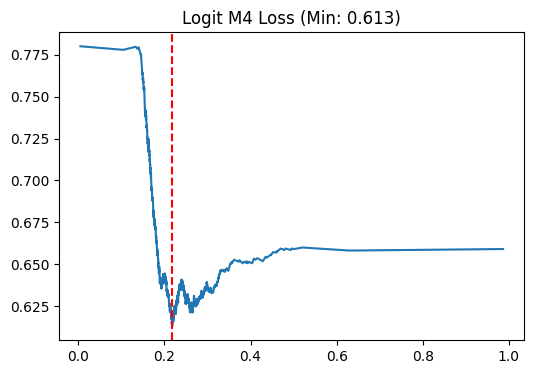


Model: Random Forest
Optimal Threshold: 0.29
Minimum Expected Loss: 0.5666


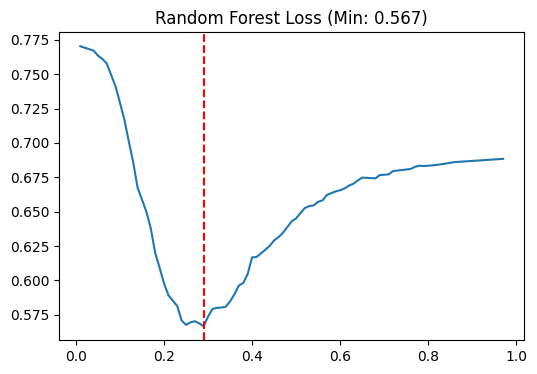


--- Confusion Matrix: Logit M4 ---
            Pred No  Pred Yes
Actual No      1532      1042
Actual Yes      327       399

--- Confusion Matrix: Random Forest ---
            Pred No  Pred Yes
Actual No      2192       742
Actual Yes      472       403


In [6]:
import pandas as pd
import numpy as np
import patsy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------------------------------
# 1. HELPER FUNCTIONS (Adapted from your notebook)
# -------------------------------------------------------------------------
def create_roc_plot(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', label='ROC curve')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.show()

def create_loss_plot(all_coords, optimal_threshold, curr_exp_loss):
    # Calculate loss for all thresholds
    all_coords['loss'] = (all_coords['false_pos'] * FP + all_coords['false_neg'] * FN) / all_coords['n']
    
    plt.figure(figsize=(8, 5))
    sns.lineplot(x=all_coords['thresholds'], y=all_coords['loss'])
    plt.axvline(x=optimal_threshold, linestyle='--', color='red')
    plt.text(optimal_threshold + 0.02, all_coords['loss'].max() * 0.9, f'Best: {round(optimal_threshold, 2)}')
    plt.xlabel('Threshold')
    plt.ylabel('Expected Loss')
    plt.title('Loss Function vs Threshold')
    plt.show()

# -------------------------------------------------------------------------
# 2. DATA SETUP & VARIABLE DEFINITION
# -------------------------------------------------------------------------
data = pd.read_csv("bisnode_firms_clean_growth.csv")

# Define Variable Lists (Same as Chapter 17, but applied to Growth)
rawvars = ["curr_assets", "curr_liab", "extra_exp", "extra_inc", "extra_profit_loss", "fixed_assets",
           "inc_bef_tax", "intang_assets", "inventories", "liq_assets", "material_exp", "personnel_exp",
           "profit_loss_year", "sales", "share_eq", "subscribed_cap"]
qualityvars = ["balsheet_flag", "balsheet_length", "balsheet_notfullyear"]
engvar = ["total_assets_bs", "fixed_assets_bs", "liq_assets_bs", "curr_assets_bs",
          "share_eq_bs", "subscribed_cap_bs", "intang_assets_bs", "extra_exp_pl",
          "extra_inc_pl", "extra_profit_loss_pl", "inc_bef_tax_pl", "inventories_pl",
          "material_exp_pl", "profit_loss_year_pl", "personnel_exp_pl"]
engvar2 = ["extra_profit_loss_pl_quad", "inc_bef_tax_pl_quad", "profit_loss_year_pl_quad", "share_eq_bs_quad"]
engvar3 = [col for col in data.columns if (col.endswith("flag_low") or col.endswith("flag_high") or col.endswith("flag_error") or col.endswith("flag_zero"))]
d1 = ["d1_sales_mil_log_mod", "d1_sales_mil_log_mod_sq", "flag_low_d1_sales_mil_log", "flag_high_d1_sales_mil_log"]
hr = ["female", "ceo_age", "flag_high_ceo_age", "flag_low_ceo_age", "flag_miss_ceo_age", "ceo_count", "labor_avg_mod", "flag_miss_labor_avg", "foreign_management"]
firm = ["age", "age2", "new", "C(ind2_cat)", "C(m_region_loc)", "C(urban_m)"]

# Define Models
# M1: Simple
M1 = ["sales_mil_log", "sales_mil_log_sq", "d1_sales_mil_log_mod", "profit_loss_year_pl", "C(ind2_cat)"]
# M4: Complex (Full Feature Set)
M4 = ["sales_mil_log", "sales_mil_log_sq"] + firm + engvar + engvar2 + engvar3 + d1 + hr + qualityvars

# RF Vars (No interactions/categoricals handled by Patsy, simplistic list for RF)
# Note: RF handles non-linearities, so we use raw + ratios, but less quad/interactions
rfvars = ["sales_mil", "d1_sales_mil_log"] + rawvars + hr + qualityvars + ["age", "ind2_cat", "m_region_loc", "urban_m"]

# -------------------------------------------------------------------------
# 3. SPLIT DATA (Train/Holdout)
# -------------------------------------------------------------------------
# Ensure target is integer
data["fast_growth"] = data["fast_growth"].astype(int)

data_train, data_holdout = train_test_split(data, train_size=0.8, random_state=42)

print("Target Balance (Train):")
print(data_train["fast_growth"].value_counts(normalize=True))

# -------------------------------------------------------------------------
# 4. PART I: PROBABILITY PREDICTION (CORRECTED)
# -------------------------------------------------------------------------

# --- A. LOGIT MODEL (M4) ---
print("\nTraining Logit Model (M4)...")
# We use distinct names (_logit) to avoid overwriting variables
y_train_logit, X_train_logit = patsy.dmatrices("fast_growth ~ " + "+".join(M4), data_train)
y_holdout_logit, X_holdout_logit = patsy.dmatrices("fast_growth ~ " + "+".join(M4), data_holdout)

# Fit Logit
logit_model = LogisticRegressionCV(
    cv=5, 
    scoring='neg_brier_score', 
    max_iter=1000, 
    random_state=42,
    n_jobs=-1
).fit(X_train_logit, y_train_logit.ravel())

# Predict Logit
logit_probs = logit_model.predict_proba(X_holdout_logit)[:, 1]
# Note: We compare logit_probs against y_holdout_logit (the shortened version)
print(f"Logit (M4) AUC: {round(roc_auc_score(y_holdout_logit, logit_probs), 3)}")

# --- B. RANDOM FOREST ---
print("\nTraining Random Forest...")

# Prep RF Data function (Repeated for clarity)
def prep_rf_data(df, var_list):
    clean_vars = [v.replace("C(", "").replace(")", "") for v in var_list]
    df_rf = df[clean_vars].copy()
    df_rf = df_rf.fillna(0) # Random Forest keeps ALL rows
    df_rf = pd.get_dummies(df_rf, drop_first=True)
    return df_rf

X_train_rf = prep_rf_data(data_train, rfvars)
X_holdout_rf = prep_rf_data(data_holdout, rfvars)

# Align columns
X_train_rf, X_holdout_rf = X_train_rf.align(X_holdout_rf, join='left', axis=1, fill_value=0)
y_train_rf = data_train["fast_growth"] # Use full length target

# Fit RF
rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=42, oob_score=True),
    {"max_features": [5, "sqrt"], "n_estimators": [100]},
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
rf_model = rf_cv.fit(X_train_rf, y_train_rf)
rf_best = rf_model.best_estimator_

# Predict RF
rf_probs = rf_best.predict_proba(X_holdout_rf)[:, 1]
# FIX: Use data_holdout["fast_growth"] (full length) for RF evaluation
print(f"Random Forest AUC: {round(roc_auc_score(data_holdout['fast_growth'], rf_probs), 3)}")

# -------------------------------------------------------------------------
# 5. PART II: CLASSIFICATION & LOSS FUNCTION
# -------------------------------------------------------------------------
FP = 1
FN = 3

def find_optimal_threshold(y_true, y_probs, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    positives = sum(y_true)
    negatives = len(y_true) - positives
    
    loss_list = []
    for i in range(len(thresholds)):
        t = thresholds[i]
        fp_count = fpr[i] * negatives
        fn_count = (1 - tpr[i]) * positives
        loss = (fp_count * FP + fn_count * FN) / len(y_true)
        loss_list.append(loss)
        
    best_idx = np.argmin(loss_list)
    best_threshold = thresholds[best_idx]
    min_loss = loss_list[best_idx]
    
    print(f"\nModel: {model_name}")
    print(f"Optimal Threshold: {round(best_threshold, 3)}")
    print(f"Minimum Expected Loss: {round(min_loss, 4)}")
    
    # Simple Plot
    plt.figure(figsize=(6, 4))
    plt.plot(thresholds, loss_list)
    plt.axvline(best_threshold, color='r', linestyle='--')
    plt.title(f'{model_name} Loss (Min: {round(min_loss,3)})')
    plt.show()
    
    return best_threshold

# Find Thresholds - Passing the CORRECT target variables now
best_thresh_logit = find_optimal_threshold(y_holdout_logit.ravel(), logit_probs, "Logit M4")
best_thresh_rf = find_optimal_threshold(data_holdout["fast_growth"], rf_probs, "Random Forest")

# -------------------------------------------------------------------------
# 6. PART III: CONFUSION MATRIX
# -------------------------------------------------------------------------
def print_confusion(y_true, probs, threshold, name):
    preds = np.where(probs >= threshold, 1, 0)
    cm = confusion_matrix(y_true, preds)
    print(f"\n--- Confusion Matrix: {name} ---")
    df_cm = pd.DataFrame(cm, index=['Actual No', 'Actual Yes'], columns=['Pred No', 'Pred Yes'])
    print(df_cm)

print_confusion(y_holdout_logit.ravel(), logit_probs, best_thresh_logit, "Logit M4")
print_confusion(data_holdout["fast_growth"], rf_probs, best_thresh_rf, "Random Forest")